
## NIO and cost






## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')

(28, 'o_coke_rt')



In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime
## !pip install pandas
## !pip install scikit-learn
## !pip install matplotlib
## !pip install seaborn
## !pip install mlxtend
## ! pip install skl2onnx



In [2]:


import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)

import os, json, time, uuid


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [3]:


import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt




/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/onnx_ops.py:159: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  tys = obj.typeStr or ''
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/automation.py:154: UserWarning: OpSchema.FormalParameter.isHomogeneous is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.is_homogeneous instead.
  if getattr(obj, 'isHomogeneous', False):
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/jinja2/environment.py:485: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  return getattr(obj, attribute)


In [4]:

import PDFshapingUtils as PDF_tk


In [5]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()


In [6]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [7]:

## Ty suggested fix where 0 needs to be 300

PDFshapingOBJ.CFD_raw_data["i_h2_temp"] = PDFshapingOBJ.CFD_raw_data["i_h2_temp"].replace(0, 300)


In [8]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,300,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


In [9]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

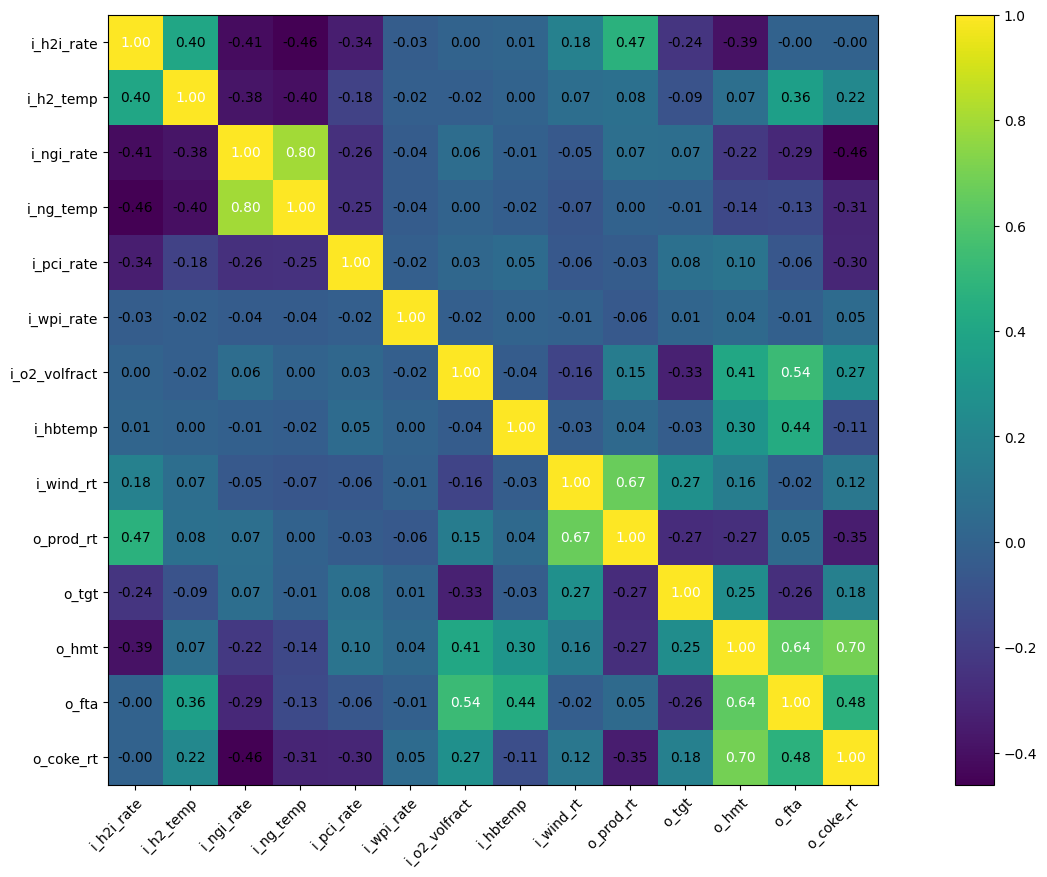

In [10]:


PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','o_prod_rt', 'o_tgt', 'o_hmt','o_fta', 'o_coke_rt']



PDFshapingOBJ.print_correlation_coefficients()


In [11]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)


In [12]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [  2, 3, 5, 6, 8, 9, 10   ] , 
                   outputs= [ 27, 29, 39, 40, 28 ]   
)


## inputs = [ 2, 3, 5, 6, 8, 9, 10  ]          ## the full 7



7
5


In [13]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 7)
(4999, 5)


In [14]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [15]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [16]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [17]:

'''


from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 4 components
pca = PCA(n_components=4)

# Fit on training data and transform both train and test
X_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)
X_test_pca  = pca.transform(PDFshapingOBJ.X_test)

# Replace the original inputs with PCA-reduced versions
PDFshapingOBJ.X_train = X_train_pca
PDFshapingOBJ.X_test  = X_test_pca


'''


'\n\n\nfrom sklearn.decomposition import PCA\n\n# Instantiate PCA to reduce to 4 components\npca = PCA(n_components=4)\n\n# Fit on training data and transform both train and test\nX_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)\nX_test_pca  = pca.transform(PDFshapingOBJ.X_test)\n\n# Replace the original inputs with PCA-reduced versions\nPDFshapingOBJ.X_train = X_train_pca\nPDFshapingOBJ.X_test  = X_test_pca\n\n\n'

In [18]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [19]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [20]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [21]:


PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## Model Forward ( 7x4 )


In [22]:

n_inputs  = 7     ## 7
n_outputs = 5




#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO_Forward(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations,  device='cuda'):
        super().__init__()
        self.device = device
        
        ## self.x_means      = x_means
        ## self.x_deviations = x_deviations
        ## self.y_means      = y_means
        ## self.y_deviations = y_deviations
        
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)
        
        
        
        ## F1
        self.f1_linear1 = nn.Linear(n_inputs, n_outputs)       
        
        ## F2
        self.f2_linear1 = nn.Linear(n_inputs, 10)
        self.f2_act1    = nn.Tanh()   ## nn.Sigmoid()    ## Tanh()    nn.ReLU()                 
        self.f2_linear2 = nn.Linear(10, n_outputs)       
        self.f2_dropout = nn.Dropout(0.25)
        
        # Move model to device
        self.to(self.device)
        
        
    ## perform inference
    def forward(self, x):
        x = x.to(self.device)
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        ##   y_descaled = torch.clamp(  y_descaled, min=0.0  )
        
        return y_descaled, y_scaled
    




In [23]:

n_inputs  = 7    ## 7
n_outputs = 5





    
class ResidualNet_Forward(nn.Module):
    def __init__(self, x_means, x_deviations, y_means, y_deviations, dropout_rate=0.1, device='cuda'):
        
        super().__init__()
        self.device = device
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)

     
        self.fc1  = nn.Linear(n_inputs, 64)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(64, n_outputs)

        # If input_dim ≠ 64, project for residual addition
        self.input_proj = nn.Linear(n_inputs, 64) if n_inputs != 64 else nn.Identity()
        
        # Move model to device
        self.to(self.device)
        

    def forward(self, x):
        x  = x.to(self.device)
        x  = (x - self.x_means) / self.x_deviations
        x0 = self.input_proj(x)
        x1 = self.dropout1(self.act1(self.fc1(x)))
        x2 = self.dropout2(self.act2(self.fc2(x1)))
        x_res = x2 + x0
        y_scaled = self.fc3(x_res)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

    


In [24]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## model_Forward     = F1plusF2_SIO_Forward(

model_Forward     =     F1plusF2_SIO_Forward(
                         PDFshapingOBJ.x_means, 
                         PDFshapingOBJ.x_deviations, 
                         PDFshapingOBJ.y_means, 
                         PDFshapingOBJ.y_deviations,
                         device=device  # pass device into the model
    
)

optimizer = optim.Adam(model_Forward.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()



In [25]:

model_Forward.train()

for epoch in range(1000):
    for xb, yb in PDFshapingOBJ.train_dl:
        
        xb = xb.to(model_Forward.device)
        yb = yb.to(model_Forward.device)
        
        optimizer.zero_grad()
        pred_descaled, pred_scaled = model_Forward(xb)
        
        loss = loss_fn(pred_scaled, yb)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(epoch, ".....", loss.item() ) 
    



0 ..... 0.5448262095451355
100 ..... 0.3644365072250366
200 ..... 0.3076404929161072
300 ..... 0.21604299545288086
400 ..... 0.1748877912759781
500 ..... 0.15062949061393738
600 ..... 0.3188650608062744
700 ..... 0.16937284171581268
800 ..... 0.1319466531276703
900 ..... 0.23480074107646942


In [26]:

print("=== SANITY CHECK: SCALING ===")
print("y_means:", PDFshapingOBJ.y_means)
print("y_deviations:", PDFshapingOBJ.y_deviations)

print("===============================================")

print("x_means:", PDFshapingOBJ.x_means)
print("x_deviations:", PDFshapingOBJ.x_deviations)


=== SANITY CHECK: SCALING ===
y_means: tensor([[  98.0982, 1307.7683, 8431.8623, 2307.8882,  417.4371]])
y_deviations: tensor([[  50.2894,  524.4169, 1506.2909,  212.0744,   49.6099]])
x_means: tensor([[  12.1255,   19.1938,   41.4359,   25.6172,  414.4036, 1438.3536,
          198.6847]])
x_deviations: tensor([[ 15.1295,  45.6381,  46.4990,   3.3245, 270.5443, 157.9123,  26.5507]])


In [27]:

print(PDFshapingOBJ.y_means -  PDFshapingOBJ.y_deviations)
print(PDFshapingOBJ.y_means +  PDFshapingOBJ.y_deviations)


tensor([[  47.8087,  783.3514, 6925.5713, 2095.8137,  367.8272]])
tensor([[ 148.3876, 1832.1852, 9938.1533, 2519.9626,  467.0470]])


In [28]:

print(PDFshapingOBJ.x_means -  PDFshapingOBJ.x_deviations)
print(PDFshapingOBJ.x_means +  PDFshapingOBJ.x_deviations)


tensor([[  -3.0039,  -26.4443,   -5.0632,   22.2926,  143.8593, 1280.4413,
          172.1340]])
tensor([[  27.2550,   64.8319,   87.9349,   28.9417,  684.9479, 1596.2660,
          225.2354]])


In [29]:

import numpy as np
from numpy.linalg import norm

# --- distance function ---
def euclid(a, b):
    return norm(a - b)



## Now add Costs


In [30]:

def regularize_z(z, strength=1e-3):
    
    return strength * torch.sum(z**2)


In [31]:

def soft_box_penalty(x, lower, upper, strength=10.0):
    
    return strength * ((torch.relu(lower - x) ** 2).sum() + (torch.relu(x - upper) ** 2).sum())


In [32]:

clamp_min = torch.tensor([[   0,   0,   0,    21,   300,   1200, 150 ]])     ## from Ty
clamp_max = torch.tensor([[ 300, 300, 300,    90,  3000,   1500, 220 ]])


get_x_from_z = lambda z: clamp_min + (clamp_max - clamp_min) * torch.sigmoid(z)


In [33]:


y_clamp_min = torch.tensor([[  100,  1710,   6400,    2000,   200 ]])     ## from Ty
y_clamp_max = torch.tensor([[  150,  1800,   6600,    2600,   500 ]])


y_clamp_min =  (y_clamp_min  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
y_clamp_max =  (y_clamp_max  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations


In [34]:

def wrapped_model(x):
    y_descaled, _ = model_Forward(x)
    return y_descaled  


In [35]:

price_real = np.array([4.0, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0])

price_real = torch.tensor(price_real, dtype=torch.float32)


model_Forward.eval()


for p in model_Forward.parameters():
    p.requires_grad = False



In [36]:

lambda_cost = 0.01        ## 0.1    ## 0.001   ## this gave 86% percent of cases improvement
## lambda_cost = 0.0

dist_method_A = []
dist_method_B = []
cost_diffs    = [] 
cost_diff     = 0

actual_pred_cost = []
actual_real_cost = []

percent_diffs = []
percent_diff  = 0 

learning_rate = 0.01        ## 0.001      ## 1e-5


In [37]:



for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    target_y  = (target_y  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
    
    ## x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point
    ## x_temp = x_starting_point.clone().detach().requires_grad_(True)
    ## z_init = torch.rand((1,7))*0.4 + 0.3
    
    z_init = torch.rand((1,7))*0.2 + 0.3
    z = torch.nn.Parameter(torch.logit(z_init))    ## this requires grad 
          

    ## x_temp = torch.randn_like(x_starting_point).requires_grad_(True)

    optimizer = torch.optim.Adam([z], lr=learning_rate)
    
   
    
    for j in range(2000):             ## 1000
        
        optimizer.zero_grad()
        
        x_temp = get_x_from_z(  z  )
        
        _, current_y = model_Forward(x_temp)
        
        
        loss_z_reg = regularize_z(z, strength=1e-3)
        
        loss_main    = torch.mean((current_y - target_y)**2)
        
        loss_ranges  = soft_box_penalty(current_y, y_clamp_min, y_clamp_max)
        
        ## loss_cost  = lambda_cost * torch.dot(price_real, x_temp)
        loss_cost  = lambda_cost * (x_temp @ price_real)
        
        loss       = loss_main + loss_cost + loss_z_reg + loss_ranges 
        
        loss.backward()
        optimizer.step()
        
        
    
        #######################
        
     
        x_temp_pred_np   = x_temp.detach().numpy()
        ## cost_pred        = np.dot(   price_real, x_temp_pred_np)
        cost_pred        = torch.dot(price_real, x_temp.squeeze()).item()
        
        x_real_np        = x_real.detach().numpy() 
        cost_real        = np.dot(price_real, x_real_np)
       
        if j % 400 == 0:           ## 20
            print(f"iteration {j} cost: {cost_pred}...H2, PCI, NGI:", x_temp_pred_np[:,:3] )
            print("real cost       :", cost_real)
            print( "total loss", loss      )
            print( "loss_main",  loss_main )
            print( "loss_cost",  loss_cost )
        
   
        cost_diff = cost_pred - cost_real
        if cost_real > 0:                         ## handle nans
            percent_diff = cost_diff / cost_real
            percent_diffs.append(percent_diff)
        
          
    cost_diffs.append(    cost_diff  )
    
    actual_pred_cost.append(  cost_pred  )
    actual_real_cost.append(  cost_real  )
      

    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    
    
    print("...")
    print("...")
    print("...")
    print( the_cols )
    print( "pred" )
    print( x_temp_pred_np )
    print( "real" )
    print( x_real_np )
    print("...")
    
    
    print( "o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt" )
    print( "y pred" )
    print( wrapped_model(torch.from_numpy(x_temp_pred_np))   )
    print( "y real" )
    print( wrapped_model(torch.from_numpy(x_real_np))   )
    
    dist_method_A.append( euclid(x_temp_pred_np, x_real_np) )
    dist_method_B.append( euclid(
                    wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().numpy() , 
                    wrapped_model(torch.from_numpy(x_real_np)).detach().numpy()
    ))
    
    print(i)
    print('********************************')
    
    ##########################################
    
    if i == 1:
        percent_errors = [[] for _ in range(5)]  # one list per output

    y_pred_np = wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().numpy().flatten()
    y_real_np = wrapped_model(torch.from_numpy(x_real_np)).detach().numpy().flatten()

    # % error per variable
    pct = (y_pred_np - y_real_np) / (y_real_np + 1e-8) * 100

    for k in range(5):
         percent_errors[k].append(pct[k])




iteration 0 cost: 774.5120849609375...H2, PCI, NGI: [[146.07668 133.17378 114.06318]]
real cost       : 80.0
total loss tensor([1104.1594], grad_fn=<AddBackward0>)
loss_main tensor(26.0879, grad_fn=<MeanBackward0>)
loss_cost tensor([7.7451], grad_fn=<MulBackward0>)
iteration 400 cost: 192.83334350585938...H2, PCI, NGI: [[38.261654 22.631279 34.310917]]
real cost       : 80.0
total loss tensor([72.1532], grad_fn=<AddBackward0>)
loss_main tensor(0.8616, grad_fn=<MeanBackward0>)
loss_cost tensor([1.9283], grad_fn=<MulBackward0>)
iteration 800 cost: 99.74702453613281...H2, PCI, NGI: [[19.133984 13.995474 18.431229]]
real cost       : 80.0
total loss tensor([16.9926], grad_fn=<AddBackward0>)
loss_main tensor(0.2331, grad_fn=<MeanBackward0>)
loss_cost tensor([0.9975], grad_fn=<MulBackward0>)
iteration 1200 cost: 74.61135864257812...H2, PCI, NGI: [[13.744668  13.137364  12.9906435]]
real cost       : 80.0
total loss tensor([11.0763], grad_fn=<AddBackward0>)
loss_main tensor(0.2649, grad_fn=<M

iteration 1600 cost: 53.942466735839844...H2, PCI, NGI: [[10.588093  4.986525 13.207141]]
real cost       : 20.5
total loss tensor([4.7669], grad_fn=<AddBackward0>)
loss_main tensor(0.1645, grad_fn=<MeanBackward0>)
loss_cost tensor([0.5394], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   7.4506855    4.194338    10.343384    24.922531   857.07086
  1491.5034     176.58781  ]]
real
[   0.    0.   41.   27.  300. 1600.  160.]
...
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
y pred
tensor([[  94.1442, 1693.6594, 6637.4048, 2503.1182,  461.1174]])
y real
tensor([[  82.0750, 1807.0981, 6235.3677, 2530.9846,  454.2372]])
5
********************************
iteration 0 cost: 668.1626586914062...H2, PCI, NGI: [[120.38926 125.85268 121.50589]]
real cost       : 80.0
total loss tensor([818.5815], grad_fn=<AddBackward0>)
loss_main tensor(18.3653, grad_fn=<MeanBackward0>)
loss_cost tensor([6.6816], grad_fn=<Mul

iteration 400 cost: 178.5198974609375...H2, PCI, NGI: [[34.553326 24.098684 32.415825]]
real cost       : 70.0
total loss tensor([63.2762], grad_fn=<AddBackward0>)
loss_main tensor(0.2342, grad_fn=<MeanBackward0>)
loss_cost tensor([1.7852], grad_fn=<MulBackward0>)
iteration 800 cost: 92.55854797363281...H2, PCI, NGI: [[17.043133 16.090769 16.590502]]
real cost       : 70.0
total loss tensor([14.6702], grad_fn=<AddBackward0>)
loss_main tensor(0.5550, grad_fn=<MeanBackward0>)
loss_cost tensor([0.9256], grad_fn=<MulBackward0>)
iteration 1200 cost: 75.68000793457031...H2, PCI, NGI: [[13.22756   16.297903  12.9437275]]
real cost       : 70.0
total loss tensor([11.5630], grad_fn=<AddBackward0>)
loss_main tensor(0.6623, grad_fn=<MeanBackward0>)
loss_cost tensor([0.7568], grad_fn=<MulBackward0>)
iteration 1600 cost: 65.48814392089844...H2, PCI, NGI: [[10.573815 17.789621 10.806521]]
real cost       : 70.0
total loss tensor([8.9399], grad_fn=<AddBackward0>)
loss_main tensor(0.7155, grad_fn=<Mea

...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   7.0298023    4.889835     8.137273    24.598335   708.16595
  1488.8379     179.57545  ]]
real
[   0.   90.    0.   30.  300. 1200.  195.]
...
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
y pred
tensor([[  98.0240, 1698.0735, 6640.5454, 2466.9895,  463.6531]])
y real
tensor([[  83.6550, 1666.1799, 8208.9648, 2350.4131,  449.8303]])
14
********************************
iteration 0 cost: 610.5430908203125...H2, PCI, NGI: [[ 99.68153 139.33636 144.96123]]
real cost       : 40.0
total loss tensor([788.4911], grad_fn=<AddBackward0>)
loss_main tensor(22.2436, grad_fn=<MeanBackward0>)
loss_cost tensor([6.1054], grad_fn=<MulBackward0>)
iteration 400 cost: 142.49636840820312...H2, PCI, NGI: [[22.606438 34.594173 34.952873]]
real cost       : 40.0
total loss tensor([32.3580], grad_fn=<AddBackward0>)
loss_main tensor(2.6855, grad_fn=<MeanBackward0>)
loss_cost tensor([1.4250], grad_fn=<Mu

iteration 800 cost: 79.11649322509766...H2, PCI, NGI: [[14.780408  12.540659  14.9084015]]
real cost       : 50.0
total loss tensor([20.4916], grad_fn=<AddBackward0>)
loss_main tensor(8.3882, grad_fn=<MeanBackward0>)
loss_cost tensor([0.7912], grad_fn=<MulBackward0>)
iteration 1200 cost: 63.24531173706055...H2, PCI, NGI: [[11.051655 13.331021 11.415344]]
real cost       : 50.0
total loss tensor([16.4249], grad_fn=<AddBackward0>)
loss_main tensor(7.9991, grad_fn=<MeanBackward0>)
loss_cost tensor([0.6325], grad_fn=<MulBackward0>)
iteration 1600 cost: 41.04889678955078...H2, PCI, NGI: [[ 6.7414274 10.059858   8.046659 ]]
real cost       : 50.0
total loss tensor([7.0276], grad_fn=<AddBackward0>)
loss_main tensor(6.3435, grad_fn=<MeanBackward0>)
loss_cost tensor([0.4105], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   5.732234     9.080748     7.1640706   23.223583   731.8079
  1486.2822     185.3523

...

...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   7.768653     2.3135571   12.824098    25.55519    328.1521
  1493.1953     174.01057  ]]
real
[   0.   90.    0.   21.  300. 1600.  195.]
...
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
y pred
tensor([[  86.7788, 1634.8972, 6707.5190, 2453.4993,  462.4619]])
y real
tensor([[ 127.2977, 1399.0098, 7354.4502, 2248.9412,  393.7541]])
980
********************************
iteration 0 cost: 543.5130004882812...H2, PCI, NGI: [[ 94.17102   97.273994 139.10988 ]]
real cost       : 80.0
total loss tensor([619.6987], grad_fn=<AddBackward0>)
loss_main tensor(15.6403, grad_fn=<MeanBackward0>)
loss_cost tensor([5.4351], grad_fn=<MulBackward0>)
iteration 400 cost: 111.45673370361328...H2, PCI, NGI: [[18.430552 24.116356 27.236345]]
real cost       : 80.0
total loss tensor([20.8757], grad_fn=<AddBackward0>)
loss_main tensor(0.2810, grad_fn=<MeanBackward0>)
loss_cost tensor([1.1146], grad_fn=

iteration 800 cost: 93.86515045166016...H2, PCI, NGI: [[11.520685 41.595943 12.372936]]
real cost       : 80.0
total loss tensor([9.7527], grad_fn=<AddBackward0>)
loss_main tensor(0.1884, grad_fn=<MeanBackward0>)
loss_cost tensor([0.9387], grad_fn=<MulBackward0>)
iteration 1200 cost: 73.88838195800781...H2, PCI, NGI: [[ 8.400934 35.753906  9.061474]]
real cost       : 80.0
total loss tensor([6.4059], grad_fn=<AddBackward0>)
loss_main tensor(0.1686, grad_fn=<MeanBackward0>)
loss_cost tensor([0.7389], grad_fn=<MulBackward0>)
iteration 1600 cost: 58.214393615722656...H2, PCI, NGI: [[ 6.193265 29.89033   7.102008]]
real cost       : 80.0
total loss tensor([3.4365], grad_fn=<AddBackward0>)
loss_main tensor(0.1902, grad_fn=<MeanBackward0>)
loss_cost tensor([0.5821], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   4.784819   24.13463     6.279057   24.482897 1333.2267   1491.2673
   173.36269 ]]
real
[ 

iteration 400 cost: 149.2794647216797...H2, PCI, NGI: [[30.09621  15.005231 27.77879 ]]
real cost       : 200.0
total loss tensor([47.6468], grad_fn=<AddBackward0>)
loss_main tensor(1.3647, grad_fn=<MeanBackward0>)
loss_cost tensor([1.4928], grad_fn=<MulBackward0>)
iteration 800 cost: 82.69081115722656...H2, PCI, NGI: [[16.621738  7.396086 17.615545]]
real cost       : 200.0
total loss tensor([14.8843], grad_fn=<AddBackward0>)
loss_main tensor(1.8937, grad_fn=<MeanBackward0>)
loss_cost tensor([0.8269], grad_fn=<MulBackward0>)
iteration 1200 cost: 65.17040252685547...H2, PCI, NGI: [[13.106989   5.9193563 13.646176 ]]
real cost       : 200.0
total loss tensor([11.1404], grad_fn=<AddBackward0>)
loss_main tensor(2.0043, grad_fn=<MeanBackward0>)
loss_cost tensor([0.6517], grad_fn=<MulBackward0>)
iteration 1600 cost: 45.660247802734375...H2, PCI, NGI: [[ 8.914683   4.986761  10.0295105]]
real cost       : 200.0
total loss tensor([3.9568], grad_fn=<AddBackward0>)
loss_main tensor(1.9444, grad

...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   9.42659     4.11346    10.494194   26.512396  362.73785  1491.5637
   170.44658 ]]
real
[  20.    0.    0.   24. 1200. 1200.  160.]
...
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
y pred
tensor([[  75.4112, 1599.5759, 6883.8350, 2497.2451,  461.5391]])
y real
tensor([[  71.7399,  854.5186, 6719.5508, 2325.0718,  431.0039]])
994
********************************
iteration 0 cost: 721.184814453125...H2, PCI, NGI: [[133.37534 129.06154 117.24389]]
real cost       : 20.5
total loss tensor([1053.0823], grad_fn=<AddBackward0>)
loss_main tensor(29.4439, grad_fn=<MeanBackward0>)
loss_cost tensor([7.2118], grad_fn=<MulBackward0>)
iteration 400 cost: 186.29559326171875...H2, PCI, NGI: [[36.427574 22.081484 37.007633]]
real cost       : 20.5
total loss tensor([68.4989], grad_fn=<AddBackward0>)
loss_main tensor(1.1441, grad_fn=<MeanBackward0>)
loss_cost tensor([1.8630], grad_fn=<MulBackw

iteration 800 cost: 84.35590362548828...H2, PCI, NGI: [[16.514935 11.361891 13.868545]]
real cost       : 60.0
total loss tensor([13.5028], grad_fn=<AddBackward0>)
loss_main tensor(0.9092, grad_fn=<MeanBackward0>)
loss_cost tensor([0.8436], grad_fn=<MulBackward0>)
iteration 1200 cost: 62.15378952026367...H2, PCI, NGI: [[11.773229 10.143459  9.834829]]
real cost       : 60.0
total loss tensor([8.7630], grad_fn=<AddBackward0>)
loss_main tensor(1.1364, grad_fn=<MeanBackward0>)
loss_cost tensor([0.6215], grad_fn=<MulBackward0>)
iteration 1600 cost: 44.599464416503906...H2, PCI, NGI: [[8.191254  8.008863  7.6511655]]
real cost       : 60.0
total loss tensor([3.0407], grad_fn=<AddBackward0>)
loss_main tensor(1.4231, grad_fn=<MeanBackward0>)
loss_cost tensor([0.4460], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   7.0585227    7.5846934    7.3080087   24.575018   688.87946
  1491.5892     179.0382   ]]

In [38]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance of Xs:")
print("Method A:", avg_A)


Average Euclidean Distance of Xs:
Method A: 605.5694


In [39]:

avg_B = np.mean(dist_method_B)


print("Average Euclidean Distance of Ys:")
print("Method A:", avg_B)


Average Euclidean Distance of Ys:
Method A: 2035.0558


In [40]:

print("average cost diff:",    np.mean(cost_diffs))
print("average percent diff:", np.mean(percent_diffs)*100, "%")


average cost diff: -49.90883240303597
average percent diff: 97.03524170127932 %


In [41]:

better = np.sum(np.array(cost_diffs) < 0)
total  = len(cost_diffs)


print("solver cheaper in:", better/total*100, "% of cases")


solver cheaper in: 79.57957957957959 % of cases


In [42]:

print(total)
print(better)


999
795


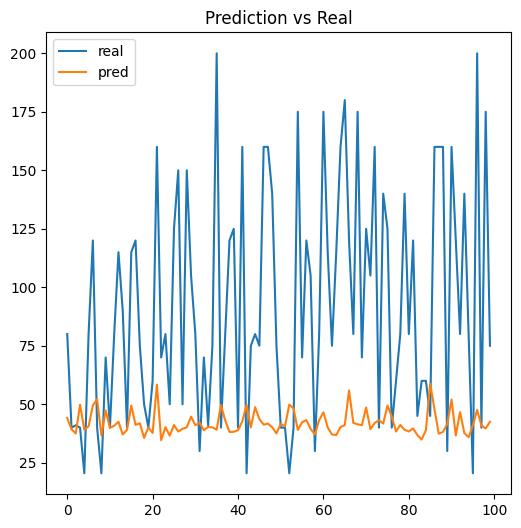

In [43]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[0:100] ,label="real")

plt.plot( pred[0:100] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


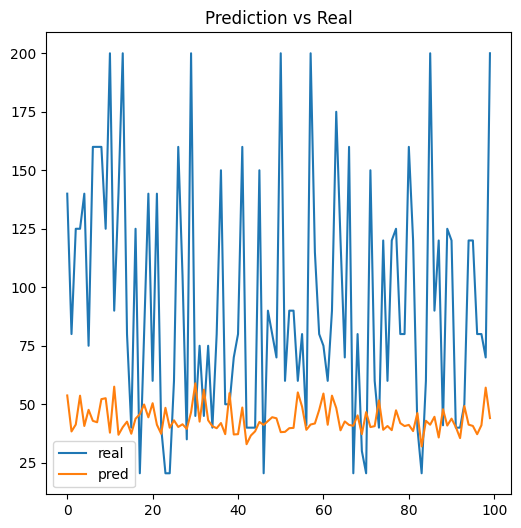

In [44]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[300:400] ,label="real")

plt.plot( pred[300:400] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


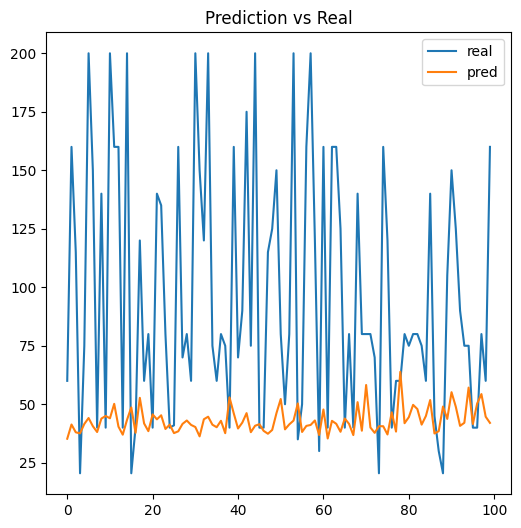

In [45]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[700:800] ,label="real")

plt.plot( pred[700:800] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


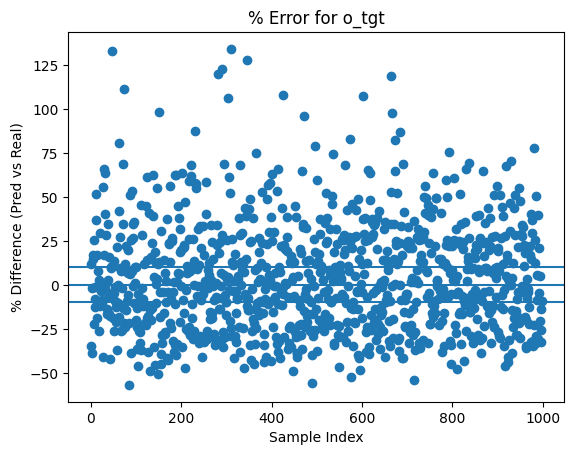

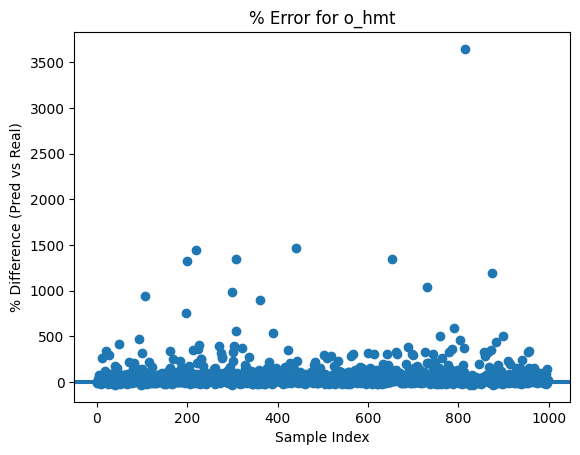

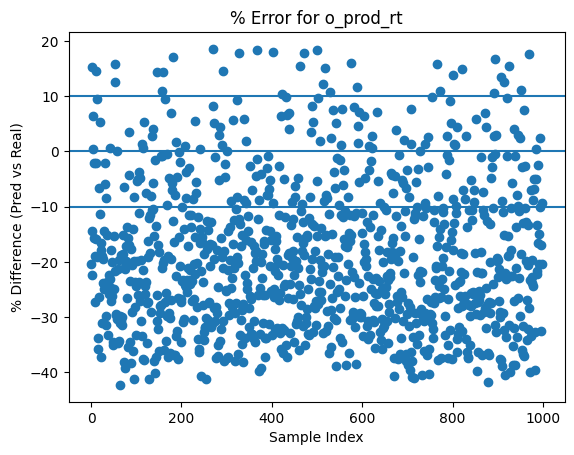

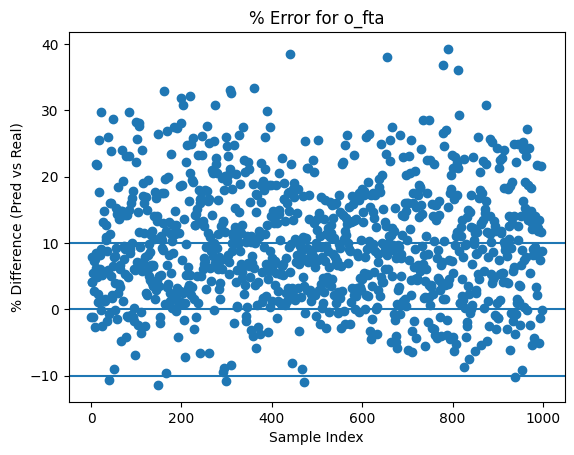

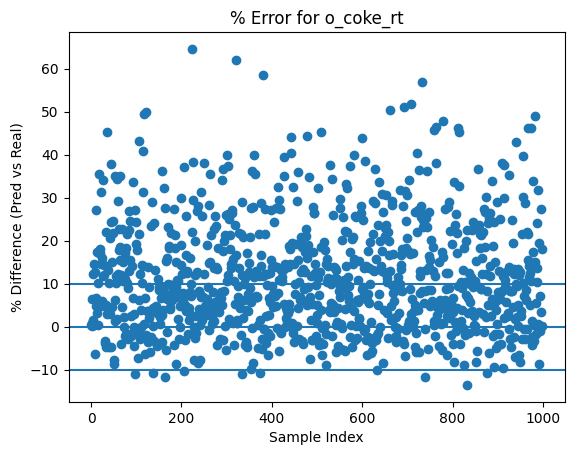

In [46]:

output_names = ['o_tgt', 'o_hmt', 'o_prod_rt', 'o_fta', 'o_coke_rt']

for k in range(5):
    plt.figure()
    plt.scatter(range(len(percent_errors[k])), percent_errors[k])
    
    plt.axhline(0)       # perfect prediction
    plt.axhline(10)      # +10% threshold
    plt.axhline(-10)     # -10% threshold
    
    plt.title(f"% Error for {output_names[k]}")
    plt.xlabel("Sample Index")
    plt.ylabel("% Difference (Pred vs Real)")
    
    plt.show()


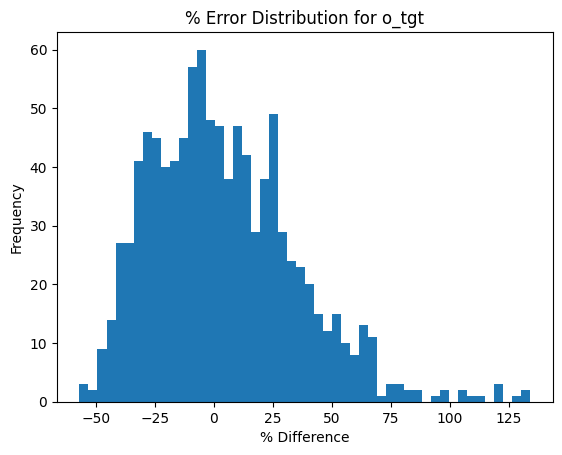

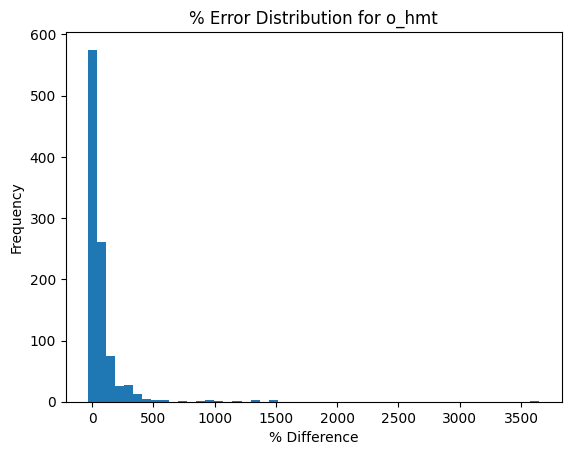

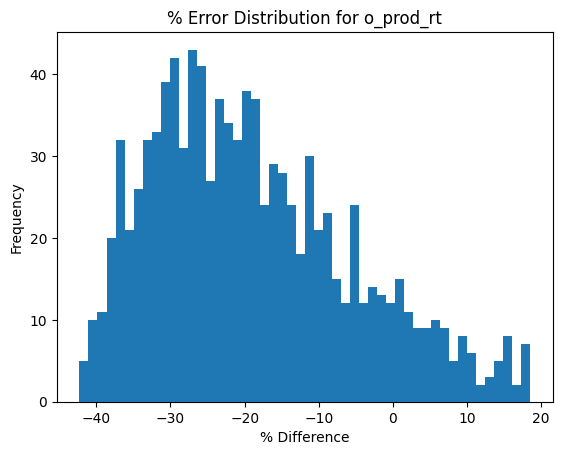

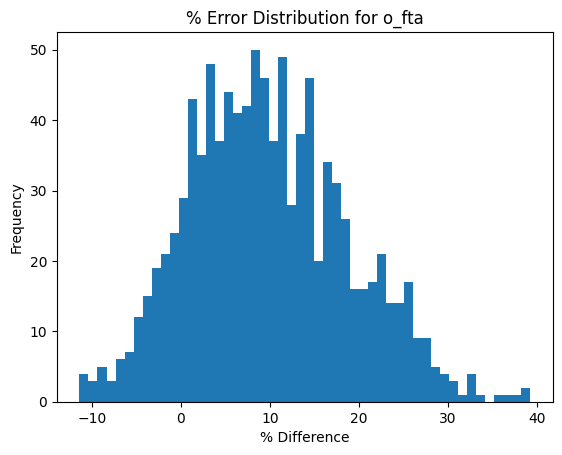

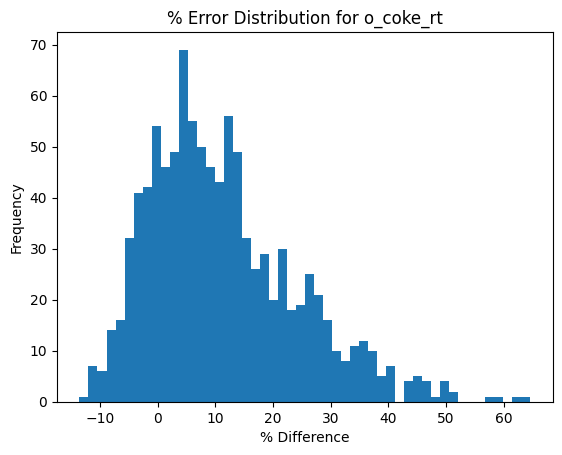

In [47]:

for k in range(5):
    plt.figure()
    plt.hist(percent_errors[k], bins=50)
    plt.title(f"% Error Distribution for {output_names[k]}")
    plt.xlabel("% Difference")
    plt.ylabel("Frequency")
    plt.show()


In [48]:

for k in range(5):
    vals = np.abs(percent_errors[k])
    within_10 = np.mean(vals <= 10) * 100
    within_5  = np.mean(vals <= 5) * 100

    print(output_names[k])
    print("  within 5% :", within_5)
    print("  within 10%:", within_10)


o_tgt
  within 5% : 12.412412412412413
  within 10%: 26.226226226226224
o_hmt
  within 5% : 11.21121121121121
  within 10%: 21.22122122122122
o_prod_rt
  within 5% : 10.11011011011011
  within 10%: 20.72072072072072
o_fta
  within 5% : 28.628628628628626
  within 10%: 53.453453453453456
o_coke_rt
  within 5% : 31.33133133133133
  within 10%: 52.35235235235235


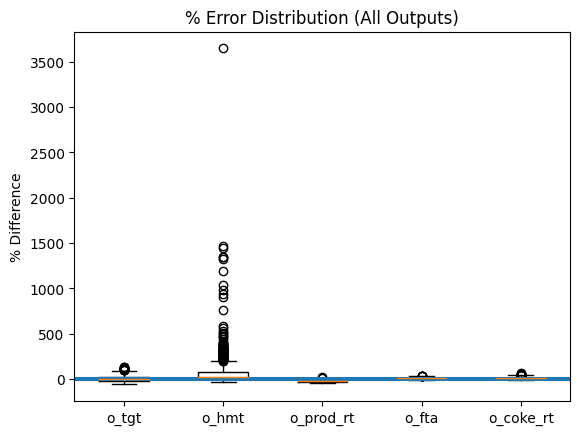

In [49]:

plt.figure()
plt.boxplot(percent_errors)
plt.xticks(range(1,6), output_names)
plt.axhline(10)
plt.axhline(-10)
plt.title("% Error Distribution (All Outputs)")
plt.ylabel("% Difference")
plt.show()


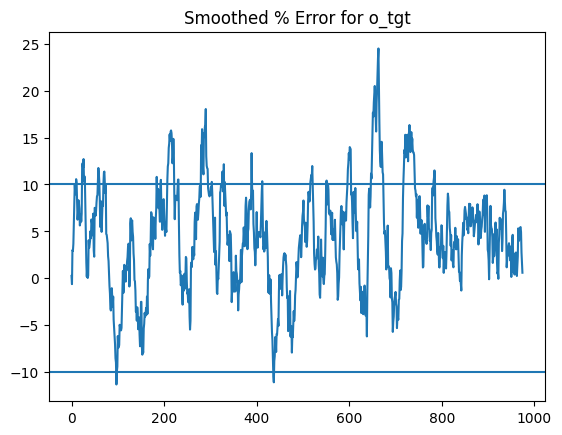

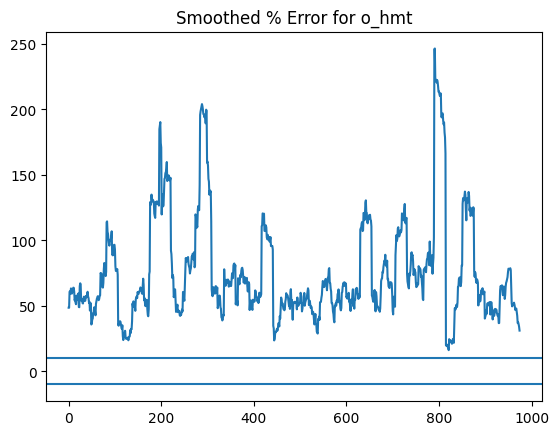

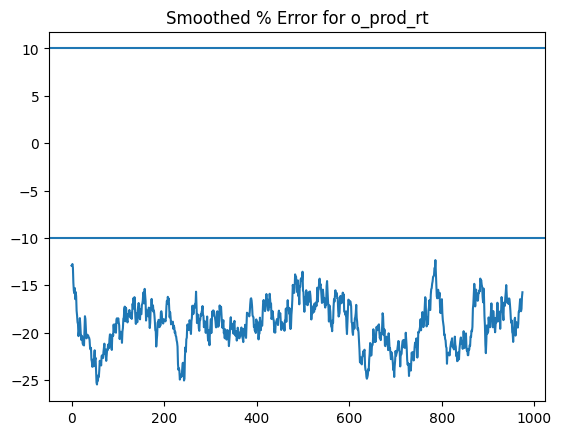

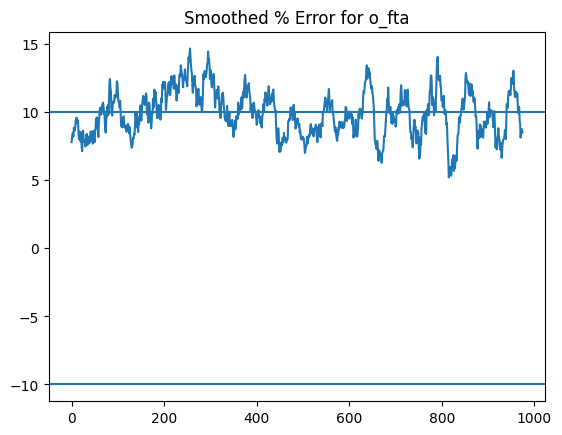

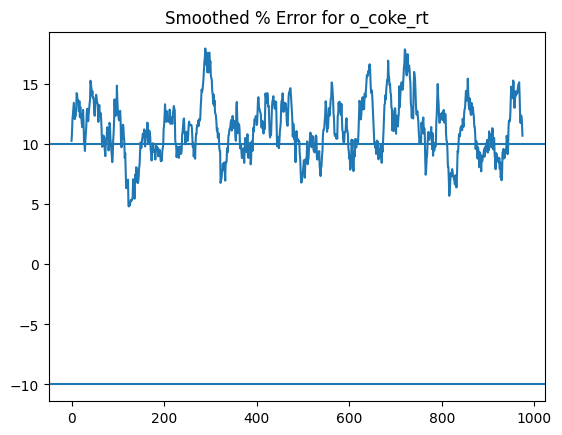

In [50]:

window = 25

for k in range(5):
    vals = np.array(percent_errors[k])
    smooth = np.convolve(vals, np.ones(window)/window, mode='valid')

    plt.figure()
    plt.plot(smooth)
    plt.axhline(10)
    plt.axhline(-10)

    plt.title(f"Smoothed % Error for {output_names[k]}")
    plt.show()


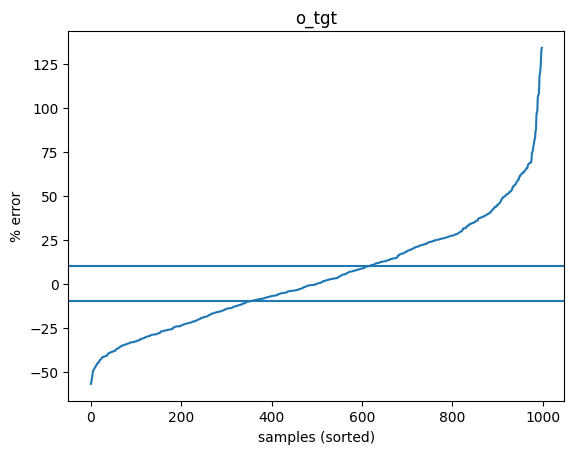

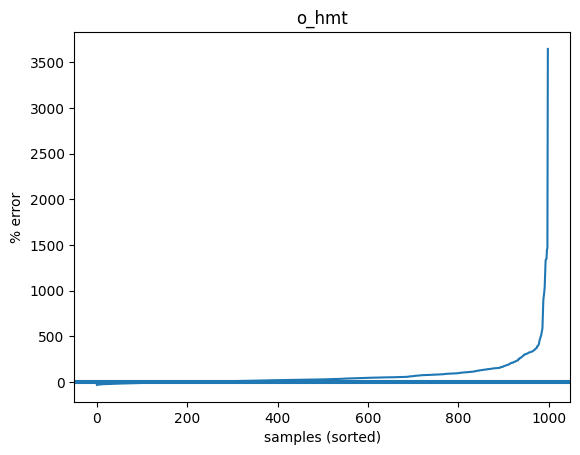

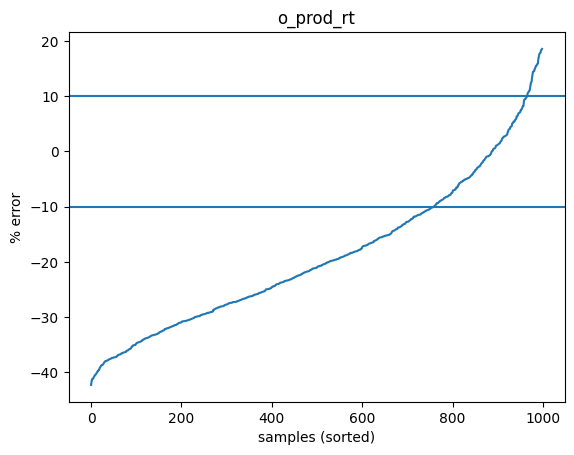

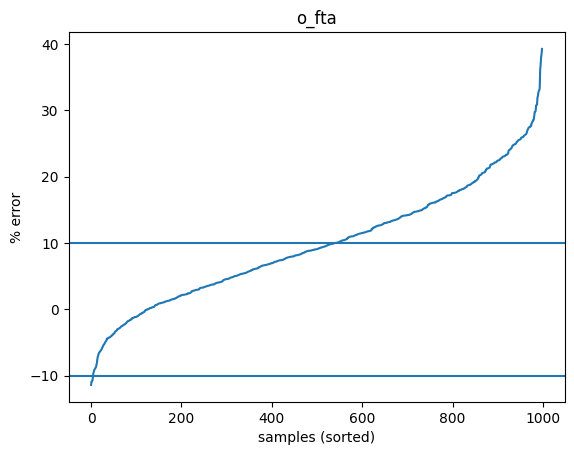

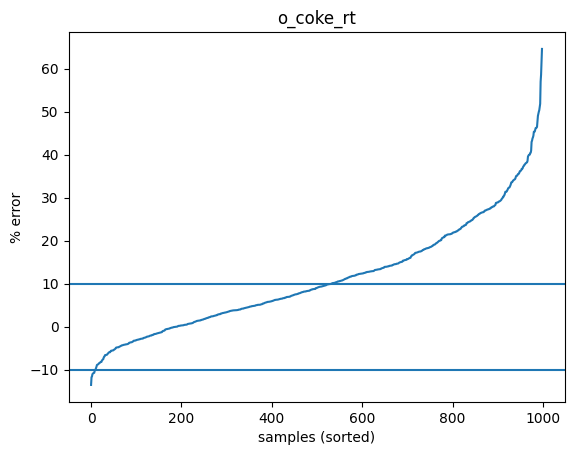

In [51]:

for k in range(5):
    vals = np.sort(np.array(percent_errors[k]))

    plt.figure()
    plt.plot(vals)
    plt.axhline(10)
    plt.axhline(-10)

    plt.title(output_names[k])
    plt.ylabel("% error")
    plt.xlabel("samples (sorted)")
    plt.show()
